In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
df=pd.read_csv('2주차_data.csv')

In [2]:
#판매량 대비 리뷰수를 새 변수로 추출

In [3]:
df['review_efficiency'] = df['log_reviews'] - df['log_downloads']

In [4]:
#게임 이름의 단어 수를 새 변수로 추출

In [5]:
df['name_len']=df['game_name'].str.len()
df[['name_len','game_name']]

,name_len,game_name
0,16,Counter-Strike 2
1,19,PUBG: BATTLEGROUNDS
2,21,ELDEN RING NIGHTREIGN
3,22,The Last of Us™ Part I
4,21,Red Dead Redemption 2
...,...,...
2375,12,Wooden House
2376,20,Shoot. Push. Repeat.
2377,14,X2: The Threat
2378,8,!AnyWay!


In [6]:
#게임 출시 월 새 변수로 추출

In [7]:
df['month'] = df['release_date'].str[-9:-6]

In [8]:
month_dict = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['month_num'] = df['month'].map(month_dict)
df[['month_num','month']]

,month_num,month
0,8,Aug
1,12,Dec
2,5,May
3,3,Mar
4,12,Dec
...,...,...
2375,9,Sep
2376,6,Jun
2377,12,Dec
2378,6,Jun


In [9]:
#결측치로 처리했던 지원언어 수의 이상치들을 중앙값으로 처리

In [10]:
df['language_count_dd']=df['language_count_dd'].fillna(df['language_count_dd'].median())
df[['language_count','language_count_dd']]

,language_count,language_count_dd
0,29,29.0
1,17,17.0
2,15,15.0
3,25,25.0
4,13,13.0
...,...,...
2375,1,1.0
2376,29,29.0
2377,8,8.0
2378,13,13.0


In [14]:
#해당 데이터셋을 이용해 변수들이 게임의 판매량에 미치는 영향력 정도를 알아보고자 함
#판매량에 의미있는 영향력을 미치는 변수를 찾기 위해서는 릿지보다 
#의미없는 변수의 계수는 0으로 만들고 다중공선성 문제 해결에 좋은 랏소를를 사용하기로 함
#추가적으로 선형모델과 비선형모델 알고리즘을 비교하기 위해 전처리가 크게 필요없는 램덤포레스트를 사용하기로 함

In [15]:
#랏소

In [17]:
#분석에 사용할 독립 변수
    #다운로드 수 대비 리뷰 수(로그), 발매년도, 제목 글자 수, 좋아요 비율, 가격, 연령 제한, 평가, 난이도, 필요 플레이 타임,  
    #지원 장르 수, 지원 언어 수(이상치 중앙값 처리), 발매월

#분석에 사용할 종속 변수
    #예상된 다운로드 건수 (판매량)(로그)

In [18]:
features = ['review_efficiency','year','name_len','reviews_like_rate', 'price', 
            'age_restriction', 'rating', 'difficulty', 'length', 'genre_count', 'language_count_dd','month_num']

In [19]:
#전체에서 20%를 테스트용으로 분리

In [20]:
x=df[features]
y=df['log_downloads']
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42)

In [21]:
#훈련 데이터 기준으로 스케일링 진행

In [22]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [23]:
#alpha는 랏소 회귀에서 변수들의 계수를 0으로 처리할 때의 기준으로 alpha 값보다 작은 계수를 지는 변수는 0으로 처리
#최적의 alpha값을 찾기 위해 0.001 부터 100까지의 alpha값을 준비하고 하나씩 대입해보면서
#교차검증 랏소 회귀 시행 

In [24]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_validate
train_scores=[]
test_scores=[]
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso=Lasso(alpha=alpha, max_iter=10000)
    scores = cross_validate(lasso, train_scaled, train_target,
    return_train_score=True)
    train_scores.append(scores['train_score'].mean())
    test_scores.append(scores['test_score'].mean())

In [27]:
#alpha 값 시각화 및 최적의 alpha값 선택
# alpha 값에 따른 훈련 세트와 검증 세트의 점수를 비교하여
# 과대적합(훈련 점수 > 검증 점수)과 과소적합(두 점수 모두 낮음)을
# 피하는 최적의 alpha 값
#이때 점수란 R^2 즉 결정계수, 설명력으로 
#추정한 회귀식, 모형에서 독립변수가 종속변수의 변화를 얼마나 잘 설명 또는 예측하는지 나타내는 정도를 말함

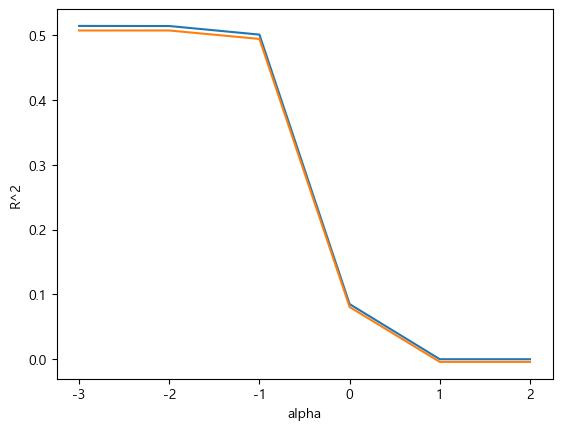

검증 점수가 가장 높은 alpha: 0.01
훈련 점수: 0.5137
검증 점수: 0.5068


In [28]:
plt.plot(np.log10(alpha_list), train_scores)
plt.plot(np.log10(alpha_list), test_scores)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()
best_idx = np.argmax(test_scores)
best_alpha = alpha_list[best_idx]

print(f"검증 점수가 가장 높은 alpha: {best_alpha}")
print(f"훈련 점수: {train_scores[best_idx]:.4f}")
print(f"검증 점수: {test_scores[best_idx]:.4f}")

In [29]:
#최종 모델 평가: 알파값 중 0.01일때 훈련 세트와 최종 테스트 세트간 정확도 차이가 작으며 (과대적합X)
#               검증점수가 가장 높음(과소적합X)

In [30]:
#0.01을 알파값으로 사용해 다시 모델 학
#모델이 데이터의 약 절반 정도 변동을 설명

In [31]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.5131959334803686
0.5687707770090051


In [32]:
#0으로 처리된 계수 확인-어떤 변수도 0으로 처리되지 않음
#데이터는 11개의 변수가 모두 의미있게 예측에 기여, 
#인위적으로 변수를 0으로 만들어 삭제하면 모델의 예측 실력이 오히려 떨어짐"

In [33]:
print(np.sum(lasso.coef_==0))

0


In [34]:
#계수들의 중요도를 보기위해 내림차순으로 정렬(스케일링 거친 데이터 이기에 이미 계수도 표준화 되어있음)

C:\Users\oyooy\AppData\Local\Temp\ipykernel_4596\3640443846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='절대값_계수',y='변수', data=dd, palette=colors)


,변수,계수,절대값_계수
8,length,0.884908,0.884908
1,year,-0.701610,0.701610
0,review_efficiency,-0.539873,0.539873
10,language_count_dd,0.516417,0.516417
4,price,0.383769,0.383769
3,reviews_like_rate,0.337431,0.337431
5,age_restriction,0.278737,0.278737
2,name_len,-0.234278,0.234278
6,rating,0.160838,0.160838
9,genre_count,0.102691,0.102691


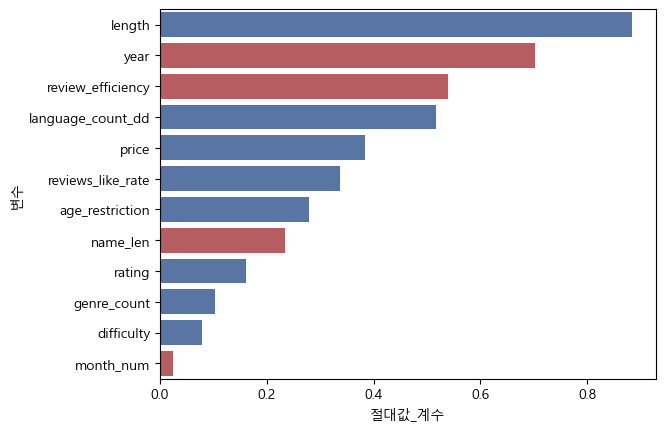

In [35]:
import seaborn as sns
col_df=pd.DataFrame({'변수':features, '계수': lasso.coef_})
col_df['절대값_계수']=col_df['계수'].abs()
dd=col_df[['변수','계수','절대값_계수']].sort_values('절대값_계수',ascending=False)
colors = ['#4C72B0' if x > 0 else '#C44E52' for x in dd['계수']]
sns.barplot(x='절대값_계수',y='변수', data=dd, palette=colors)
dd

In [36]:
#계수 해석
#게임 플레이 타임이 길수록 누적 판매량에 긍정적 영향을 주며 이는 숏폼이 크게 유행하는 요즘 미디어 시장과
#구별되는 게임 이용자들의 성향때문이라고 할 수 있음
#또한 발매년도의 계수가 음수 인것을 통해 알 수 있듯 게임은 단기간의 높은 판매량을 기록하는 것 외에도
#시장에 오래 살아남아 스테디셀러로 자리잡는 것도 판매량 확보에 유리함을 알 수 있음
#지원하는 언어의 수, 좋아요 비율, 평가, 지원 장르 수는 높을 수록 누적 판매량에 당연하게 긍정적 영향을 미쳤고
#그중 지원 언어의 수가 전체에서 4등으로 높은 중요도를 보인것을 통해 스팀이 전세계의 나라에서 사용할 수 있는 게임 판매 플랫폼이기에 
#다양한 국가의 소비자를 확보하는 것이 중요함을 알 수 있음
#의외로 가격과 연령 제한,난이도도 높을 수록 누적 판매량이 높은 것으로 나타났다.
#이는 스팀 이용자들이 주로 성인이기에 연령제한에 대상이 아니며
#퀄리티가 높고 현실적이고 자극적인 비싼 가격의 게임들을 선호한다는 것을 보여준다.
#또한 판매량 대비 리뷰수의 경우 음수로 나타났는데 이는 대다수의 소비자가 구매물품에 리뷰를 달지 않듯
#판매량 대비 리뷰수가 많은 게임이 다수의 사람보다는 특정 매니아층에게만 소비되고 있음을 시사함
#또한 발매월 변수를 통해 미세하게나마 연초 출시작이 연말 출시작보다 유리하다는 것을 알 수 있음

In [40]:
# 오분류 분석 - 오차가 가장 큰 상위 3개 게임
#전반적으로 데이터들이 회귀선 주위에 분포 하지만 일부 실제 판매량이 높은 게임을 과소평가하는
#경향이 나타난 것으로 보아 모델에 포함시키지 못한 독립변수가 있다는 것을 알 수 있음

오차가 가장 큰 상위 3개 게임
                                                     이름  실제 누적 판매량  예상 누적 판매량  \
2304                                             Banana  15.876024   9.064566   
51                              Call of Duty®: Warzone™  18.070414  12.206728   
291   Business Tour - Board Game with Online Multipl...  16.134953  10.902150   

        잔차 절대값  
2304  6.811458  
51    5.863686  
291   5.232803  


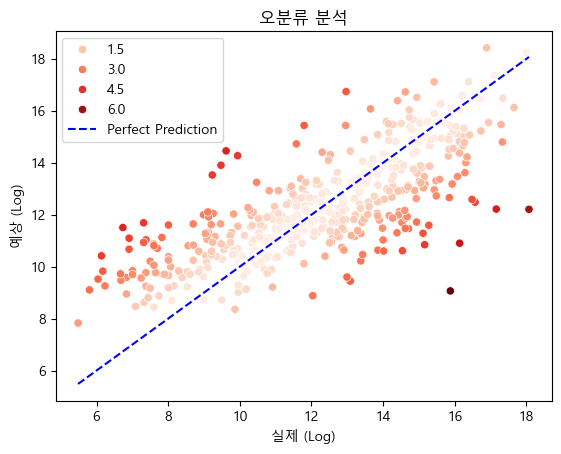

In [41]:
#테스트 세트에 대한 예측값 계산
y_pred = lasso.predict(test_scaled)

#테스트 세트에 대한 예측값과 실제 값, 그 차이
error_analysis_df = pd.DataFrame({
    '이름': df.loc[test_input.index, 'game_name'],  # 게임 제목
    '실제 누적 판매량': test_target.values,
    '예상 누적 판매량': y_pred,
    '잔차 절대값': np.abs(test_target.values - y_pred)})

#오차가 가장 큰 상위 3개
top_errors = error_analysis_df.sort_values(by='잔차 절대값', ascending=False).head(3)

print("오차가 가장 큰 상위 3개 게임")
print(top_errors[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']])

#시각화: 실제값 vs 예측값 
sns.scatterplot(data=error_analysis_df, x='실제 누적 판매량', y='예상 누적 판매량', hue='잔차 절대값', palette='Reds')
plt.plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color='blue', linestyle='--', label='Perfect Prediction')
plt.title('오분류 분석')
plt.xlabel('실제 (Log)')
plt.ylabel('예상 (Log)')
plt.legend()
plt.show()

In [42]:
#잔차 패턴 분석
#0을 중심으로 고르게 분포, 패턴이 없는 무작위 성을 보여
#전반적인 모델의 예측 신뢰도는 양호한 것으로 평가

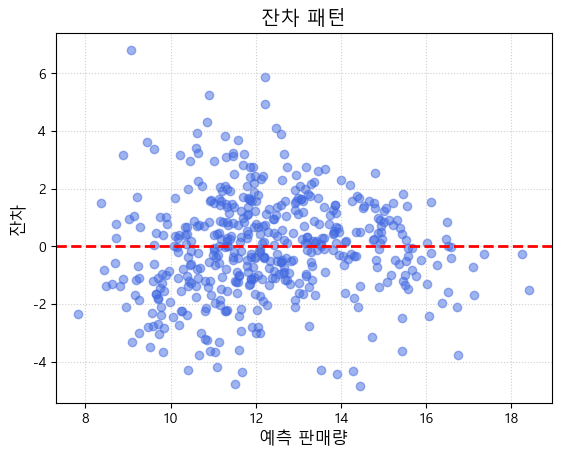

In [43]:
residuals = test_target.values - y_pred

plt.scatter(y_pred, residuals, alpha=0.5, color='royalblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선

plt.title('잔차 패턴', fontsize=14)
plt.xlabel('예측 판매량', fontsize=12)
plt.ylabel('잔차', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [44]:
#회귀 분석이지만 해당 데이터에서 판매량 상위30%를 흥행작으로 가정하고 분류 모델 처럼 평가해서
#해당 머신러닝 모델의 성능을 평가
#Confusion Matrix와 ROC Curve시행

In [45]:
#Confusion Matrix
#진짜 비흥행을 맞힘: 망할 것 같은 게임 315개 정확히 예측
#진짜 흥행을 맞힘: 흥행할 것 같은 게임 79개 정확히 예측
#예측 실패: 실제로는 흥행한 64개의 게임에 대해 모델은 실패할 거라고 예측
#예측 실패: 실제로는 흥행하지 못한 18개의 게임에 대해 흥행할 것이라고 잘못 예측

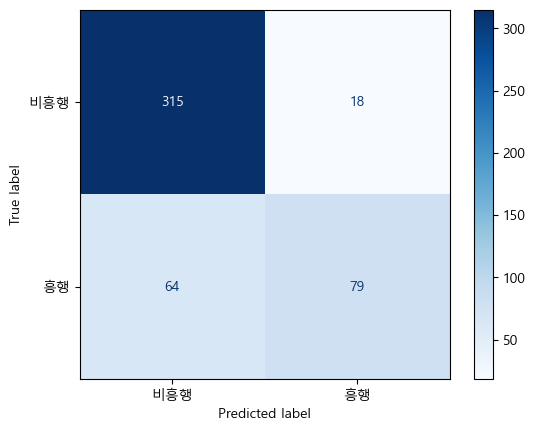

정확도: 82.8%
전체 게임 10개 중 8개 이상의 흥행여부 정확히 예측
정밀도: 81.4%
흥행예측이 81.4%의 확률로 성공


In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#상위 30퍼를 흥행으로 정의 하고 이를 넘는 값은 흥행(1)으로 나머지는 0으로 정의
threshold = np.percentile(test_target, 70)
y_actual = (test_target > threshold).astype(int)
y_pred_a = (y_pred> threshold).astype(int)

cm = confusion_matrix(y_actual, y_pred_a)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['비흥행', '흥행'])
disp.plot(cmap='Blues', values_format='d')
plt.show()
print(f'정확도: {(315 + 79) / 476*100:,.1f}%')
print('전체 게임 10개 중 8개 이상의 흥행여부 정확히 예측')
print(f'정밀도: {79 / (79 + 18)*100:,.1f}%')
print('흥행예측이 81.4%의 확률로 성공')

In [47]:
#ROC Curve
#y축은 흥행작을 흥작이라고 예측할 확률, x축은 흥행작이 아닌데 흥행작이라고 예측할 확률을 의미
#왼쪽 위 모서리에 곡선이 붙을 수 록 즉 흥행작만을 전부 골라 흥행작이라고 예측한다면 판별능력이 뛰어나다고 봄
#AUC값은 곡선아래의 면적의 수치로 해당 모델은 0.8769로 준수하다고 할 수 있음
#즉 구체적인 판매량을 예측하는데는 오차가 있지만 어떤게임이 흥행할 것인지 판별하는 능력은 괜찮음을 알 수 있음

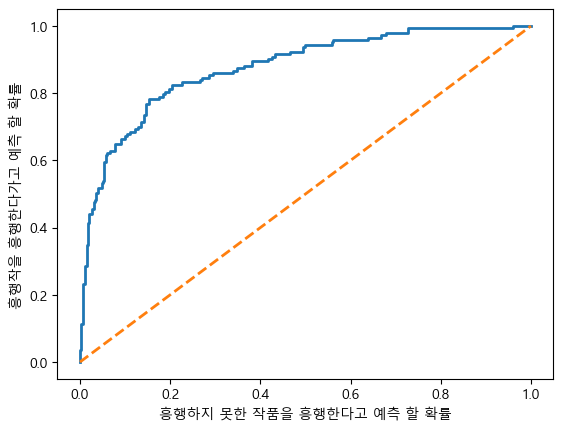

최종 AUC 점수: 0.8767


In [48]:
from sklearn.metrics import roc_curve, auc

# 회귀 모델의 예측값(y_pred)을 분류 확률값처럼 사용
fpr, tpr, thresholds = roc_curve(y_actual, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2)
plt.plot([0, 1], [0, 1], lw=2, linestyle='--') # 가이드라인

plt.xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
plt.ylabel('흥행작을 흥행한다가고 예측 할 확률')
plt.show()

print(f"최종 AUC 점수: {roc_auc:.4f}")

In [49]:
#랜덤 포레스트 알고리즘
#훈련 점수가 검증 변수와 비교했을때 매우 커 과대적합으로 보임
#하이퍼파라미터 튜닝이 필요해보임

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
rf= RandomForestRegressor(random_state=42)
rf_scores = cross_validate(rf, train_input, train_target, return_train_score=True)

In [51]:
rf_train_score=rf_scores['train_score'].mean()
rf_test_score=rf_scores['test_score'].mean()
print(rf_train_score)
print(rf_test_score)

0.9451940086217391
0.6050303434805684


In [52]:
#이산적인 후보군에서 벗어나고 하이퍼파라미터를 효율적으로 탐색하기 위해 베이지안 최적화 사
#베이지안 최적화를 통해 최적의 파라미터(트리 모델의 깊이, 나무의 수 , 가지치기에 필요한 최소 샘플수)와
#그때의 검증 점수 구하기
#최적의 파라미터 값: 깊이-18 , 나무수-500, 가지치기에 필요한 최소 샘플수-2

In [53]:
from skopt import BayesSearchCV
from skopt.space import Integer
search_spaces = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(5, 20),
    'min_samples_split': Integer(2, 20)
}
opt = BayesSearchCV(RandomForestRegressor(random_state=42),
    search_spaces, n_iter=30, cv=5, n_jobs=-1, random_state=42)
opt.fit(train_input, train_target)
print("베이지안 최적화 결과:", opt.best_params_)
print("최고 검증 점수:", opt.best_score_)

베이지안 최적화 결과: OrderedDict([('max_depth', 18), ('min_samples_split', 2), ('n_estimators', 500)])
최고 검증 점수: 0.606554696093103


In [63]:
bm = opt.best_estimator_
bm_train_score = bm.score(train_input, train_target)
bm_test_score = bm.score(test_input, test_target)
print(bm_train_score)

0.947943775042331


In [55]:
#여전히 과적합이기에 하이퍼파리미터의 조건을 강력하게 조정하여 다시 시행

In [57]:
spaces_t = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(3, 8),            # 깊이를 확 낮춤
    'min_samples_split': Integer(50, 150), # 가지치기 조건 강화
    'min_samples_leaf': Integer(20, 50)    # 가지치기 조건 강화
}
opt_t = BayesSearchCV(RandomForestRegressor(random_state=42),
    spaces_t, n_iter=20, cv=5, n_jobs=-1, random_state=42)
opt_t.fit(train_input, train_target)

bm_t = opt_t.best_estimator_
print(f"새로운 훈련 점수: {bm_t.score(train_input, train_target):.4f}")
print(f"새로운 검증 점수: {opt_t.best_score_:.4f}")

새로운 훈련 점수: 0.6532
새로운 검증 점수: 0.5561


In [59]:
#해당 모델에 사용된 변수의 중요도 추출
#랏소의 계수와 비교했을때 상위 3위 까지의 순위는 같으나 
#랜덤포레스트에서는 평가의 중요도가 4위로 높아졌고 영향력은 거의 없으나 랏소에서 꼴지였던 지원 장르의 수가 9위로 높아졌다
#이는 랜덤포레스트가 선형성을 지닌 랏소가 파악하지 못한 변수들의 비선형적 관계를 중요하게 인식한 결과이다.
#반대로 랏소는 랜덤포레스트에서는 알 수 없는 변수들의 방향성을 알 수 있다.

                   변수       중요도                 변수        계수    절대값_계수
0              length  0.360868             length  0.884908  0.884908
1                year  0.239082               year -0.701610  0.701610
2   review_efficiency  0.133573  review_efficiency -0.539873  0.539873
3   language_count_dd  0.096484  language_count_dd  0.516417  0.516417
4              rating  0.069047              price  0.383769  0.383769
5               price  0.040999  reviews_like_rate  0.337431  0.337431
6   reviews_like_rate  0.026691    age_restriction  0.278737  0.278737
7     age_restriction  0.017707           name_len -0.234278  0.234278
8            name_len  0.008024             rating  0.160838  0.160838
9          difficulty  0.003947        genre_count  0.102691  0.102691
10          month_num  0.002525         difficulty  0.078382  0.078382
11        genre_count  0.001053          month_num -0.024857  0.024857


C:\Users\oyooy\AppData\Local\Temp\ipykernel_4596\2143131032.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='절대값_계수',y='변수', data=dd, palette=colors,ax=ax[0])


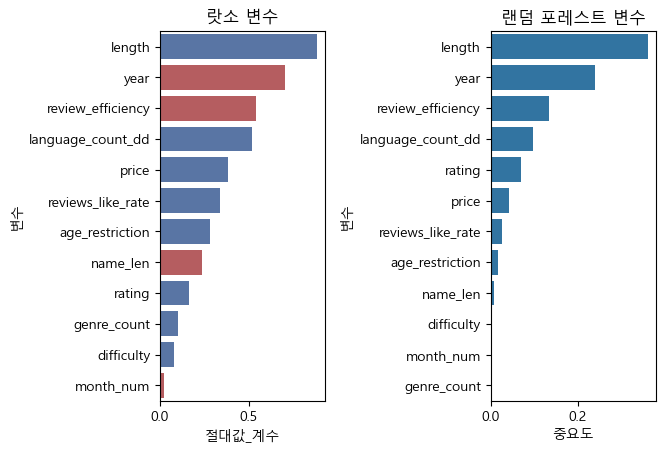

In [64]:
feature_importance_df = pd.DataFrame({
    '변수': features,
    '중요도': bm_t.feature_importances_
})
fi=feature_importance_df.sort_values('중요도', ascending=False)
print(pd.concat(
    [fi.reset_index(drop=True),
     dd.reset_index(drop=True)],
    axis=1
))
fig, ax=plt.subplots(1,2)
sns.barplot(x='절대값_계수',y='변수', data=dd, palette=colors,ax=ax[0])
ax[0].set_title('랏소 변수')
sns.barplot(x='중요도',y='변수', data=fi,ax=ax[1])
ax[1].set_title('랜덤 포레스트 변수')
plt.subplots_adjust(wspace=1)
plt.show()

In [65]:
#랏소와 랜덤 포레스트의 테스트 점수를 비교하면 랏소가 더 예측력이 좋다는 것을 알 수 있음
#과대 적합 정도도 랏소가 더 낮아 랏소가 안정성이 더 높다고 할 수 있음
#즉 게임의 정확한 예측 판매량을 구하기 위해서는 랏소가 더 적합하다

In [66]:
print(f"랏소 테스트 점수: {lasso.score(test_scaled, test_target)}")
print(f"랜덤 포레스트 테스트 점수: {opt_t.best_score_}")
print(f"랏소 과대 적합 정도: {lasso.score(train_scaled, train_target)- lasso.score(test_scaled, test_target)}")
print(f"랜덤 포레스트 과대적합 정도: {bm_t.score(train_input, train_target)-opt_t.best_score_}")

랏소 테스트 점수: 0.5687707770090051
랜덤 포레스트 테스트 점수: 0.5561235534888367
랏소 과대 적합 정도: -0.05557484352863651
랜덤 포레스트 과대적합 정도: 0.09705651649171809


In [67]:
#두 모델의 학습시간 비교
#랏소보다 랜덤 포레스트가 더 복잡한 알고리즘이기에 학습도 더 오랜시간 소비되었다.

In [68]:
import time

start = time.time()
lasso.fit(train_scaled, train_target)
lasso_time = time.time() - start

start = time.time()
bm_t.fit(train_input, train_target) # 이미 튜닝된 파라미터로 학습
rf_time = time.time() - start

print(f"Lasso 학습 시간: {lasso_time:.4f}초")
print(f"Random Forest 학습 시간: {rf_time:.4f}초")

Lasso 학습 시간: 0.0010초
Random Forest 학습 시간: 0.3708초


In [75]:
#오분류 분석 비교
#모델에 따라 오차가 큰 상위 3개 게임도 다르게 나타남
#그래프도 약간의 차이를 보임

In [71]:
#테스트 세트에 대한 예측값 계산
y_pred_bm = bm_t.predict(test_input)

#테스트 세트에 대한 예측값과 실제 값, 그 차이
error_analysis_bm = pd.DataFrame({
    '이름': df.loc[test_input.index, 'game_name'],  # 게임 제목
    '실제 누적 판매량': test_target.values,
    '예상 누적 판매량': y_pred_bm,
    '잔차 절대값': np.abs(test_target.values - y_pred_bm)})

#오차가 가장 큰 상위 3개 샘플
top_errors_bm = error_analysis_bm.sort_values(by='잔차 절대값', ascending=False).head(3)
print("오차가 가장 큰 상위 3개 게임 랜덤 포레스트와 랏소")
print(pd.concat(
    [top_errors_bm[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']].reset_index(drop=True),
     top_errors[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']].reset_index(drop=True)], axis=1))
top3_error_bm = error_analysis_bm.sort_values(by='잔차 절대값', ascending=False).head(3).index
top3_error_df = error_analysis_df.sort_values(by='잔차 절대값', ascending=False).head(3).index
print("\n오차가 가장 큰 상위 3개 게임(랜덤 포레스트)")
aa = list(features)
aa.insert(0,'game_name')
display(df.loc[top3_error_bm, aa])
print('\nLords Mobile: 리뷰수가 판매량보다 높은 데이터 노이즈')
print('예측 한계')
print('Banana: 무료, 연령제한 0세, 난이도 낮은데 높은 판매량 - NFT와 같은 수익성 목적으로 많이 판매되었음')
print('Call of Duty®: Warzone™: 좋아요 비율이 매우 낮고, 무료 이지만 높은 판매량 - 유명 시리즈 작품\n')
display(df.loc[top3_error_df, aa])
print("\n오차가 가장 큰 상위 3개 게임(랏소)")
print('예측 한계')
print('Banana: 무료, 연령제한 0세, 난이도 낮은데 높은 판매량 - NFT와 같은 수익성 목적으로 많이 판매되었음')
print('Call of Duty®: Warzone™: 좋아요 비율이 매우 낮고, 무료 이지만 높은 판매량 - 유명 시리즈 작품')
print('Business Tour - Board Game with Online Multiplayer: 이름이 매우 길고 무료, 연령제한 0세, 난이도도 낮은데 높은 판매량 - 저사양/캐주얼 장르로서 대중적')

오차가 가장 큰 상위 3개 게임 랜덤 포레스트와 랏소
                        이름  실제 누적 판매량  예상 누적 판매량    잔차 절대값  \
0             Lords Mobile   5.484797  13.893186  8.408389   
1                   Banana  15.876024  10.018609  5.857415   
2  Call of Duty®: Warzone™  18.070414  12.748370  5.322044   

                                                  이름  실제 누적 판매량  예상 누적 판매량  \
0                                             Banana  15.876024   9.064566   
1                            Call of Duty®: Warzone™  18.070414  12.206728   
2  Business Tour - Board Game with Online Multipl...  16.134953  10.902150   

     잔차 절대값  
0  6.811458  
1  5.863686  
2  5.232803  

오차가 가장 큰 상위 3개 게임(랜덤 포레스트)


,game_name,review_efficiency,year,name_len,reviews_like_rate,price,age_restriction,rating,difficulty,length,genre_count,language_count_dd,month_num
508,Lords Mobile,3.148044,2019,12,66,0.0,0,2.75,1,45,2,18.0,6
2304,Banana,-4.473974,2024,6,82,0.0,0,1.08,1,1,2,4.0,4
51,Call of Duty®: Warzone™,-7.360919,2022,23,31,0.0,17,2.88,3,19,3,14.0,11



Lords Mobile: 리뷰수가 판매량보다 높은 데이터 노이즈
예측 한계
Banana: 무료, 연령제한 0세, 난이도 낮은데 높은 판매량 - NFT와 같은 수익성 목적으로 많이 판매되었음
Call of Duty®: Warzone™: 좋아요 비율이 매우 낮고, 무료 이지만 높은 판매량 - 유명 시리즈 작품



,game_name,review_efficiency,year,name_len,reviews_like_rate,price,age_restriction,rating,difficulty,length,genre_count,language_count_dd,month_num
2304,Banana,-4.473974,2024,6,82,0.0,0,1.08,1,1,2,4.0,4
51,Call of Duty®: Warzone™,-7.360919,2022,23,31,0.0,17,2.88,3,19,3,14.0,11
291,Business Tour - Board Game with Online Multipl...,-4.887074,2017,50,60,0.0,0,2.20,2,9,3,23.0,7



오차가 가장 큰 상위 3개 게임(랏소)
예측 한계
Banana: 무료, 연령제한 0세, 난이도 낮은데 높은 판매량 - NFT와 같은 수익성 목적으로 많이 판매되었음
Call of Duty®: Warzone™: 좋아요 비율이 매우 낮고, 무료 이지만 높은 판매량 - 유명 시리즈 작품
Business Tour - Board Game with Online Multiplayer: 이름이 매우 길고 무료, 연령제한 0세, 난이도도 낮은데 높은 판매량 - 저사양/캐주얼 장르로서 대중적


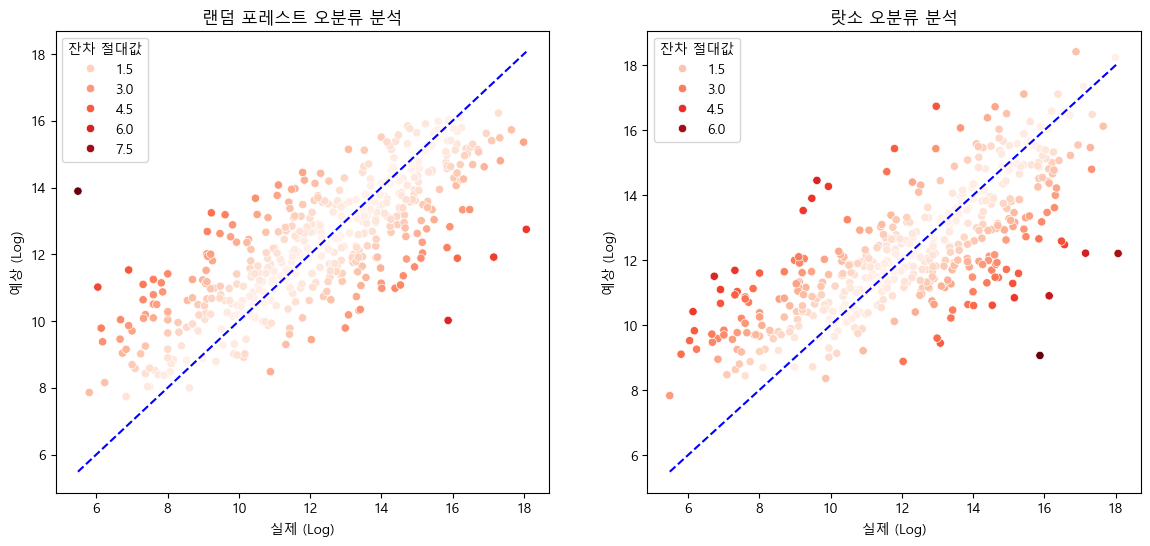

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(data=error_analysis_bm, x='실제 누적 판매량', y='예상 누적 판매량', hue='잔차 절대값', palette='Reds',ax=ax[0])
ax[0].plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color='blue', linestyle='--')
ax[0].set_title('랜덤 포레스트 오분류 분석')
ax[0].set_xlabel('실제 (Log)')
ax[0].set_ylabel('예상 (Log)')

sns.scatterplot(data=error_analysis_df, x='실제 누적 판매량', y='예상 누적 판매량', hue='잔차 절대값', palette='Reds',ax=ax[1])
ax[1].plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color='blue', linestyle='--', label='Perfect Prediction')
ax[1].set_title('랏소 오분류 분석')
ax[1].set_xlabel('실제 (Log)')
ax[1].set_ylabel('예상 (Log)')
plt.show()

In [73]:
#잔차 패턴 분석 비교
#두 모델의 잔차 패턴 모두 0을 중심으로 무작위적으로 분포 되어있으나
#랏소의 경우가 더 넓게 퍼지며 낮은 판매량 구간에서 비교적 잔차 분산이 더 크고
#판매량이 커질수록 잔차 분산이 줄어드는 경향을 보이며 이를 통해
#랜덤 포레스트에 비해 랏소 모델은 낮은 판매량 영역에서 약간 큰 예측 오차를 보일 가능성을 시사한다.

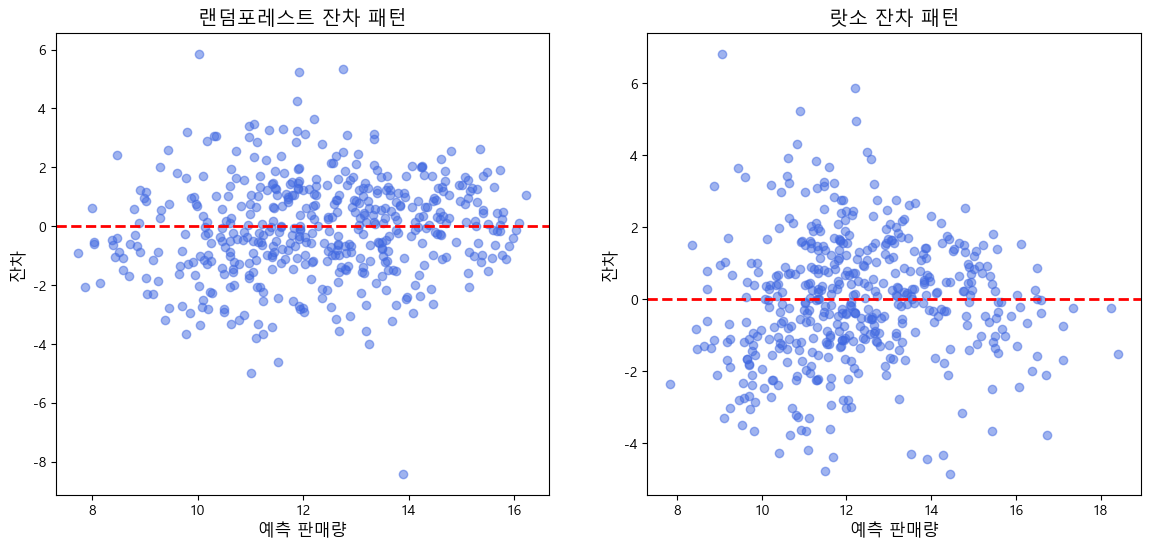

In [74]:
residuals_bm = test_target.values - y_pred_bm
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].scatter(y_pred_bm, residuals_bm, alpha=0.5, color='royalblue')
ax[0].axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선
ax[0].set_title('랜덤포레스트 잔차 패턴', fontsize=14)
ax[0].set_xlabel('예측 판매량', fontsize=12)
ax[0].set_ylabel('잔차', fontsize=12)

ax[1].scatter(y_pred, residuals, alpha=0.5, color='royalblue')
ax[1].axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선
ax[1].set_title('랏소 잔차 패턴', fontsize=14)
ax[1].set_xlabel('예측 판매량', fontsize=12)
ax[1].set_ylabel('잔차', fontsize=12)
plt.show()

In [76]:
#잔차 분석을 통해 두 모델 모두 심각한 데이터 편향 없이 학습되었음을 검증하였으며
#오분류 분석을 통해 단순 수치만으로는 예측하기 어려운 특이 사례(Outlier)의 존재를 확인하여 
#모델의 예측 한계와 데이터의 노이즈 구간을 찾아냈다.

In [77]:
#회귀 분석이지만 랏소 모델과 마찬가지로 해당 데이터에서 판매량 상위30%를 
#흥행작으로 가정하고 분류 모델 처럼 평가해서 해당 머신러닝 모델의 성능을 평가
#Confusion Matrix와 ROC Curve시행

In [78]:
#랜덤포레스트 Confusion Matrix
#진짜 비흥행을 맞힘: 망할 것 같은 게임 315개 정확히 예측
#진짜 흥행을 맞힘: 흥행할 것 같은 게임 86개 정확히 예측
#예측 실패: 실제로는 흥행한 57개의 게임에 대해 모델은 실패할 거라고 예측
#예측 실패: 실제로는 흥행하지 못한 18개의 게임에 대해 흥행할 것이라고 잘못 예측

#정확도와 정밀도 모두 랜덤 포레스트가 높음

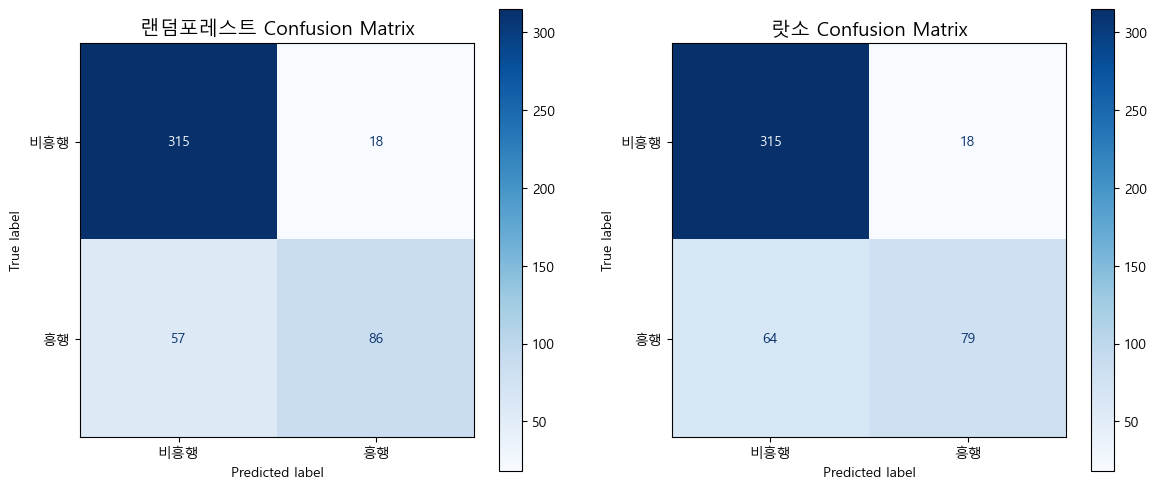

랜덤 포레스트 정확도: 84.2%
랏소 정확도: 82.8%
랜덤 포레스트 정밀도: 82.7%
랏소 정밀도: 81.4%


In [79]:
y_pred_b = (y_pred_bm> threshold).astype(int)
cm_b = confusion_matrix(y_actual, y_pred_b)
disp_bm = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['비흥행', '흥행'])

fig, ax = plt.subplots(1, 2, figsize=(14,6))
disp_bm.plot(cmap='Blues', values_format='d',ax=ax[0])
ax[0].set_title('랜덤포레스트 Confusion Matrix', fontsize=14)
disp.plot(cmap='Blues', values_format='d',ax=ax[1])
ax[1].set_title('랏소 Confusion Matrix', fontsize=14)
plt.show()
print(f'랜덤 포레스트 정확도: {(315 + 86) / 476*100:,.1f}%')
print(f'랏소 정확도: {(315 + 79) / 476*100:,.1f}%')
print(f'랜덤 포레스트 정밀도: {86 / (86 + 18)*100:,.1f}%')
print(f'랏소 정밀도: {79 / (79 + 18)*100:,.1f}%')

In [82]:
#랜덤포레스트 ROC Curve
#랜덤포레스트의 AUC값은 0.8961로 준수하며 랏소의 AUC값보다 크고
#앞에서 살펴보았듯 정확도와 정밀도 모두 랜덤 포레스트가 높아
#랜덤포레스트가 랏소보다 어떤 게임이 흥행할 것인지 판별하는 능력은 뛰어남 알 수 있음

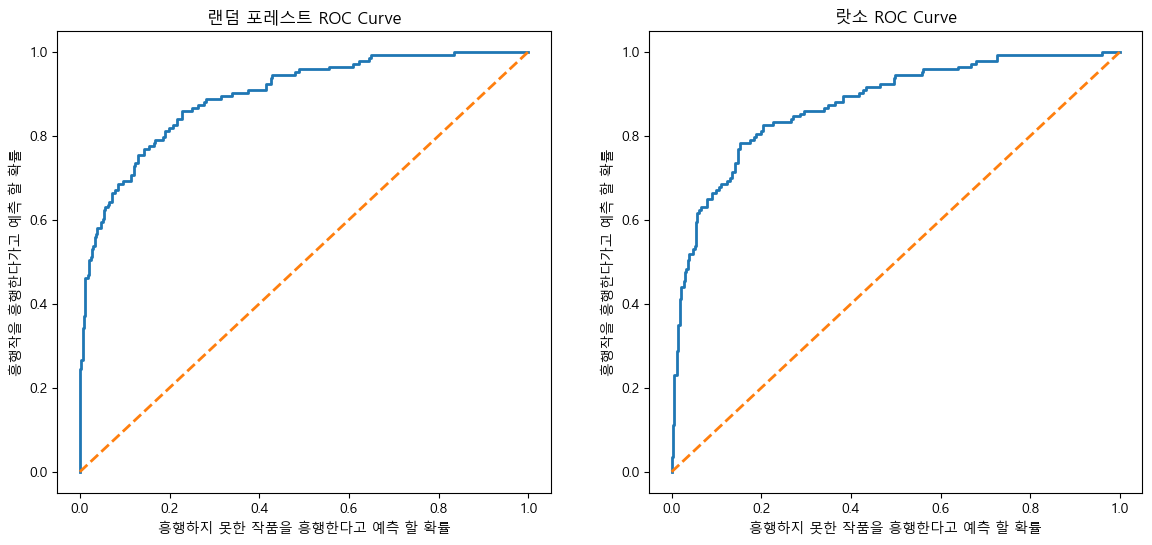

랜덤 포레스트 AUC 점수: 0.8961
랏소 AUC 점수: 0.8767


In [83]:
fpr_bm, tpr_bm, thresholds = roc_curve(y_actual, y_pred_bm)
roc_auc_bm = auc(fpr_bm, tpr_bm)

fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(fpr_bm, tpr_bm, lw=2)
ax[0].plot([0, 1], [0, 1], lw=2, linestyle='--')
ax[0].set_xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
ax[0].set_ylabel('흥행작을 흥행한다가고 예측 할 확률')
ax[0].set_title('랜덤 포레스트 ROC Curve')

ax[1].plot(fpr, tpr, lw=2)
ax[1].plot([0, 1], [0, 1], lw=2, linestyle='--')
ax[1].set_xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
ax[1].set_ylabel('흥행작을 흥행한다가고 예측 할 확률')
ax[1].set_title('랏소 ROC Curve')
plt.show()

print(f"랜덤 포레스트 AUC 점수: {roc_auc_bm:.4f}")
print(f"랏소 AUC 점수: {roc_auc:.4f}")